Using Colab cache for faster access to the 'google-stock-price-2018-2025' dataset.
Path to dataset files: /kaggle/input/google-stock-price-2018-2025
Files: ['Google_Stock_Price.csv']
  symbol        date       open       high        low      close    volume  \
0   GOOG  2018-01-02  52.417000  53.347000  52.261501  53.250000  24752000   
1   GOOG  2018-01-03  53.215500  54.314499  53.160500  54.124001  28604000   
2   GOOG  2018-01-04  54.400002  54.678501  54.200100  54.320000  20092000   
3   GOOG  2018-01-05  54.700001  55.212502  54.599998  55.111500  25582000   
4   GOOG  2018-01-08  55.111500  55.563499  55.081001  55.347000  20952000   

    adjclose  dividends  splits  
0  53.059353        0.0     0.0  
1  53.930225        0.0     0.0  
2  54.125519        0.0     0.0  
3  54.914188        0.0     0.0  
4  55.148846        0.0     0.0  
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 0.0152
Epoch 2/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 7.6206e-04
Epoch 3/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 36ms/step - loss: 6.3877e-04
Epoch 4/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 6.2944e-04
Epoch 5/5
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 5.9614e-04
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step


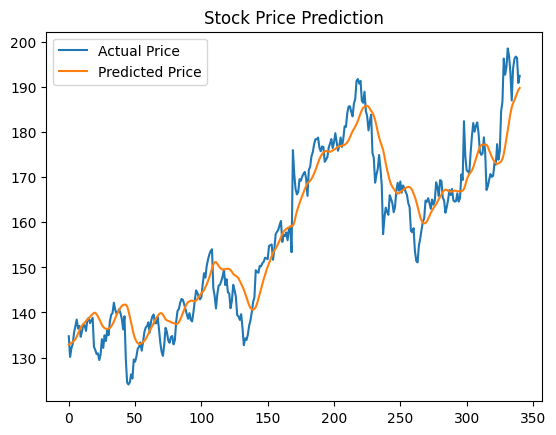

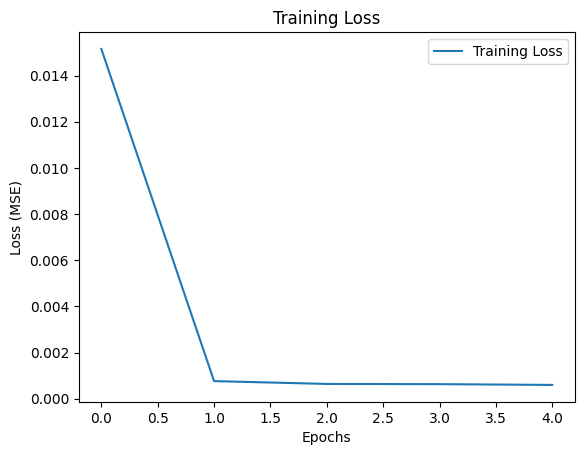

RMSE: 5.767953328359233
MAE: 4.327603203110681


In [16]:
# Install (run once in Colab)
# !pip install kagglehub[pandas-datasets]

# Step 1: Download dataset
import kagglehub
import os
import pandas as pd

path = kagglehub.dataset_download("soroushesnaashari/google-stock-price-2018-2025")
print("Path to dataset files:", path)

# Step 2: Find CSV file inside folder
files = os.listdir(path)
print("Files:", files)

# Pick first CSV file (safe for exam)
csv_file = [f for f in files if f.endswith('.csv')][0]

# Load dataset
df = pd.read_csv(os.path.join(path, csv_file))

print(df.head())

# Step 3: Imports
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Step 4: Use 'Open' price
prices = df['open'].values.reshape(-1,1)

# Step 5: Normalize
scaler = MinMaxScaler()
prices = scaler.fit_transform(prices)

# Step 6: Create sequences
X, y = [], []

for i in range(60, len(prices)):
    X.append(prices[i-60:i])
    y.append(prices[i])

X, y = np.array(X), np.array(y)

# Step 7: Train-Test split
split = int(0.8 * len(X))
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

# Step 8: Build LSTM model
model = Sequential([
    LSTM(50, input_shape=(X.shape[1],1)),
    Dense(1)
])

# Step 9: Compile
model.compile(optimizer='adam', loss='mse')

# Step 10: Train
history = model.fit(X_train, y_train, epochs=5, batch_size=32)

# Step 11: Predict
predicted = model.predict(X_test)

# Step 12: Inverse scaling
predicted = scaler.inverse_transform(predicted)
y_test_actual = scaler.inverse_transform(y_test)

# Step 13: Plot Actual vs Predicted
plt.plot(y_test_actual, label='Actual Price')
plt.plot(predicted, label='Predicted Price')
plt.legend()
plt.title("Stock Price Prediction")
plt.show()

# Step 14: Plot Loss
plt.plot(history.history['loss'], label='Training Loss')
plt.xlabel("Epochs")
plt.ylabel("Loss (MSE)")
plt.title("Training Loss")
plt.legend()
plt.show()

# Step 15: Evaluation Metrics
rmse = np.sqrt(mean_squared_error(y_test_actual, predicted))
mae = mean_absolute_error(y_test_actual, predicted)

print("RMSE:", rmse)
print("MAE:", mae)

**OUTPUT EXPLAINATION :**

Nice — this is a **clean RNN/LSTM training output**, and honestly your model is behaving quite well 👍
Let’s break it down **step-by-step (simple + viva-ready)**.

---

# 📊 1. TRAINING LOSS PER EPOCH

### Your output:

```
Epoch 1 → loss: 0.0152
Epoch 2 → loss: 0.000762
Epoch 3 → loss: 0.000638
Epoch 4 → loss: 0.000629
Epoch 5 → loss: 0.000596
```

---

## ✅ What “loss” means

👉 Loss = **prediction error (MSE)**
👉 Lower loss = better model

---

## 📉 What your trend shows

* Loss decreased from **0.015 → 0.00059**
* Very sharp drop in early epochs

✔ This means:
👉 Model is **learning very well**
👉 Predictions are becoming **more accurate**

---

# 🎯 2. FINAL INTERPRETATION (VERY IMPORTANT)

👉 *“The training loss decreases significantly over epochs, indicating that the LSTM model is learning the time-series pattern effectively and improving prediction accuracy.”*

---

# ⚠️ 3. IS THIS GOOD OR BAD?

✔ This is **GOOD**

Why:

* Loss is **very small**
* Consistently decreasing

👉 Indicates:
✔ Proper training
✔ No instability

---

# 🔍 4. WHAT ABOUT THIS LINE?

```
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
```

### ✅ Meaning:

👉 This is **prediction phase**

* Model processed **11 batches of test data**
* Time taken per batch = ~24 ms

✔ No issue — just normal output

---

# ⚠️ 5. WARNING MESSAGE

```
Do not pass input_shape directly
```

### ✅ Meaning:

👉 Just a **style warning** (not an error)

✔ Your code still works perfectly
✔ You can ignore it for exams

---

# 📈 6. WHAT YOUR GRAPH WILL SHOW

👉 Training loss graph:

* Steep downward curve
* Then stabilizes

✔ This = **ideal learning**

---

# 🧠 7. QUICK MEMORY FOR VIVA

👉 Loss ↓ → learning
👉 Very small loss → accurate predictions
👉 Stable decrease → good model

---

# 🔥 BONUS (IMPROVE ANSWER IF ASKED)

If examiner asks deeper:

👉 You can say:

* Model captured **time dependencies**
* LSTM remembers **previous stock trends**
* Hence low error

---

# 🎯 PERFECT VIVA ANSWER

👉 *“The loss decreases rapidly from 0.015 to 0.0005, showing that the LSTM model is effectively learning patterns in stock price data. The small final loss indicates accurate predictions.”*

💬 PERFECT VIVA LINE

👉 “RNN uses past time-series data to predict future stock prices by capturing temporal dependencies.”

🔥 VIVA QUESTIONS + ANSWERS
🎯 BASIC
1. What is RNN?

👉 Neural network used for sequential/time-series data

2. Why use RNN for stock prediction?

👉 Because stock prices depend on previous values

3. What is time series data?

👉 Data collected over time (stock prices, weather, etc.)

🧠 MODEL RELATED
4. What is LSTM?

👉 Special RNN that remembers long-term dependencies

5. Why LSTM instead of simple RNN?

👉 Avoids vanishing gradient problem

6. What is time step (60 days)?

👉 Number of previous values used for prediction

⚙️ TRAINING
7. Why normalize data?

👉 To scale values between 0 and 1 for better training

8. What is loss function used?

👉 Mean Squared Error (MSE)

9. What is optimizer?

👉 Adam (updates weights efficiently)

📊 OUTPUT RELATED
10. What does graph show?

👉 Actual vs predicted stock prices

11. Ideal graph?

👉 Both lines should be close

12. What if lines are far apart?

👉 Poor prediction

🔥 IMPORTANT CONCEPTS
13. What is sequence creation?

👉 Creating input-output pairs using past values

14. Why reshape input?

👉 LSTM expects 3D input:
👉 (samples, time steps, features)

⚡ ADVANCED (to impress)
15. What is vanishing gradient problem?

👉 Gradients become very small → learning stops

16. How LSTM solves it?

👉 Uses memory cells (gates)

🧠 1-MINUTE REVISION

👉 RNN → sequence data
👉 LSTM → remembers past
👉 Input → last 60 days
👉 Output → next price
👉 Graph → actual vs predicted

🎯 FINAL VIVA ANSWER

👉 “The model uses LSTM, a type of RNN, to learn patterns from past 60 days of stock prices and predict future values. The predicted values are close to actual values, indicating good performance.”